# Mini Trabalho 3 — Exploração dos Dados
**Universidade de Brasília — UnB | Aprendizado de Máquina**

**Grupo 5:**
- Gustavo Costa de Jesus — 211061814
- Harleny Angéllica Araújo de Sousa — 211061832
- João Pedro Araújo de Freitas Lyra — 232003661
- Raquel Ferreira Andrade — 211062437

## 1. Imports e Configuração

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## 2. Carregamento dos Dados

In [31]:
ratings = pd.read_csv('ml-latest-small/ratings.csv')
movies = pd.read_csv('ml-latest-small/movies.csv')
tags = pd.read_csv('ml-latest-small/tags.csv')



## 3. Visão Geral

In [32]:
print(ratings.head())
print(movies.head())
print(tags.head())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId              tag   timestamp
0       2    60756            funny  1445714994
1       2    60756  Highly quotable  1445714996
2       2    60756     will ferre

In [33]:
print(f'ratings: {ratings.shape}')
print(f'movies: {movies.shape}')
print(f'tags: {tags.shape}')

ratings: (100836, 4)
movies: (9742, 3)
tags: (3683, 4)


## 4. Qualidade dos Dados(Nulos e Duplicatas)

In [34]:
print(ratings.isnull().sum())
print(movies.isnull().sum())
print(tags.isnull().sum())
print()
print(f'Duplicatas ratings: {ratings.duplicated().sum()}')
print(f'Duplicatas movies: {movies.duplicated().sum()}')
print(f'Duplicatas tags: {tags.duplicated().sum()}')

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
movieId    0
title      0
genres     0
dtype: int64
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

Duplicatas ratings: 0
Duplicatas movies: 0
Duplicatas tags: 0


## 5. Análise das Avaliações

In [35]:
print(ratings['rating'].describe())

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


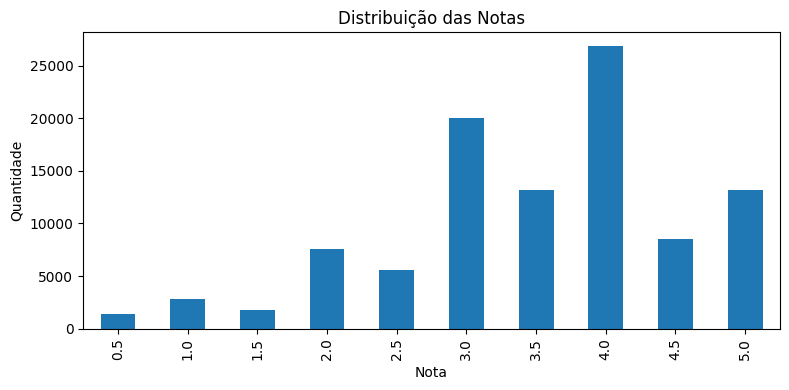

In [36]:
plt.figure(figsize=(8, 4))
ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribuição das Notas')
plt.xlabel('Nota')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.tight_layout()
plt.savefig('assets/distribuicao_notas.png')
plt.show()

## 6. Avaliações por Usuário

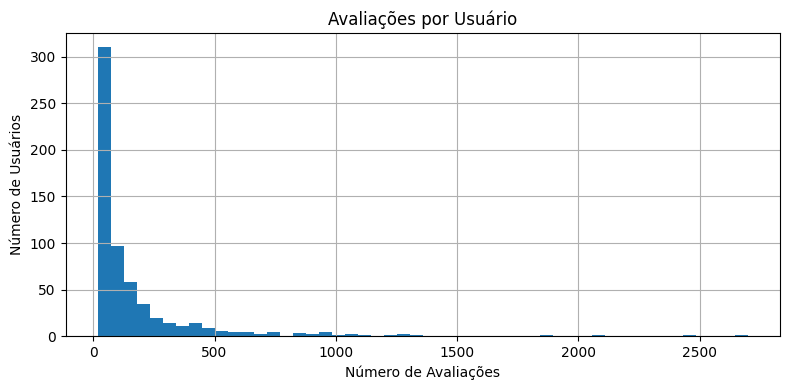

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: rating, dtype: float64


In [37]:
avaliacoes_por_usuario = ratings.groupby('userId')['rating'].count()
plt.figure(figsize=(8, 4))
avaliacoes_por_usuario.hist(bins=50)
plt.title('Avaliações por Usuário')
plt.xlabel('Número de Avaliações')
plt.ylabel('Número de Usuários')
plt.tight_layout()
plt.savefig('assets/avaliacoes_por_usuario.png')
plt.show()

print(avaliacoes_por_usuario.describe())

## 7. Avaliações por Filme e TOP 10 Filmes Mais Avaliados

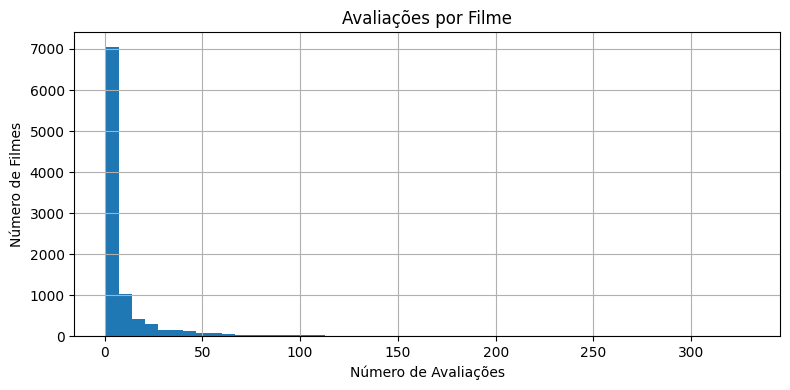

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: rating, dtype: float64


In [38]:
avaliacoes_por_filme = ratings.groupby('movieId')['rating'].count()
plt.figure(figsize=(8, 4))
avaliacoes_por_filme.hist(bins=50)
plt.title('Avaliações por Filme')
plt.xlabel('Número de Avaliações')
plt.ylabel('Número de Filmes')
plt.tight_layout()
plt.savefig('assets/avaliacoes_por_filme.png')
plt.show()

print(avaliacoes_por_filme.describe())

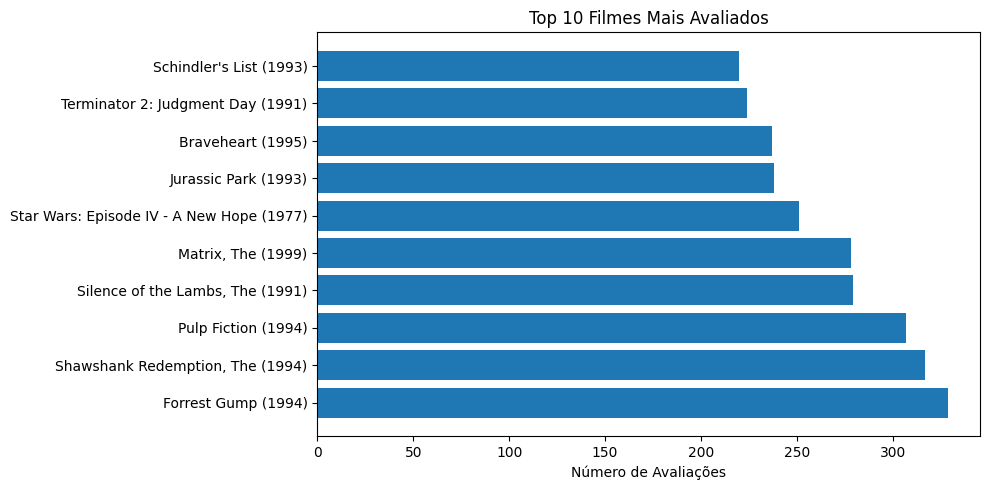

In [39]:
top10 = (
    ratings.groupby('movieId')['rating']
    .count()
    .nlargest(10)
    .reset_index()
    .merge(movies[['movieId', 'title']], on='movieId')
)

plt.figure(figsize=(10, 5))
plt.barh(top10['title'], top10['rating'])
plt.title('Top 10 Filmes Mais Avaliados')
plt.xlabel('Número de Avaliações')
plt.tight_layout()
plt.savefig('assets/top10_filmes.png')
plt.show()

## 8. Análise por Gênero

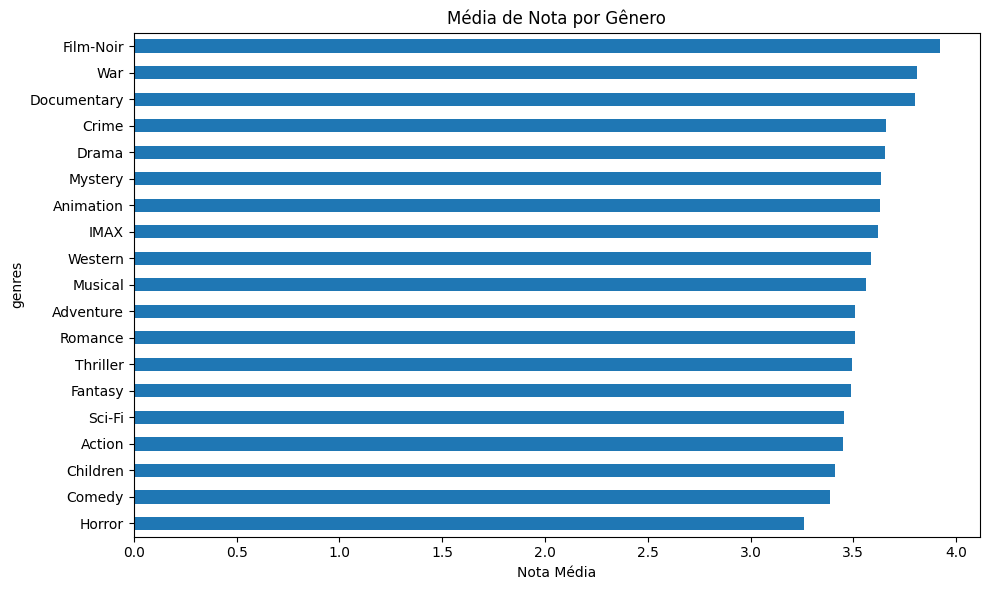

In [40]:
movies_generos = movies.copy()
movies_generos['genres'] = movies_generos['genres'].str.split('|')
movies_exploded = movies_generos.explode('genres')
movies_exploded = movies_exploded[movies_exploded['genres'] != '(no genres listed)']

rating_genero = ratings.merge(movies_exploded[['movieId', 'genres']], on='movieId')

media_genero = rating_genero.groupby('genres')['rating'].mean().sort_values()

plt.figure(figsize=(10, 6))
media_genero.plot(kind='barh')
plt.title('Média de Nota por Gênero')
plt.xlabel('Nota Média')
plt.tight_layout()
plt.savefig('assets/media_por_genero.png')
plt.show()


## 9. Esparsidade da Matriz Usuário-Filme

In [41]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)

esparcidade = 1 - (n_ratings / (n_users * n_movies))

print(f'Usuários: {n_users}')
print(f'Filmes: {n_movies}')
print(f'Avaliações: {n_ratings}')
print(f'Esparcidade: {esparcidade*100:.2f}% ')

Usuários: 610
Filmes: 9724
Avaliações: 100836
Esparcidade: 98.30% 


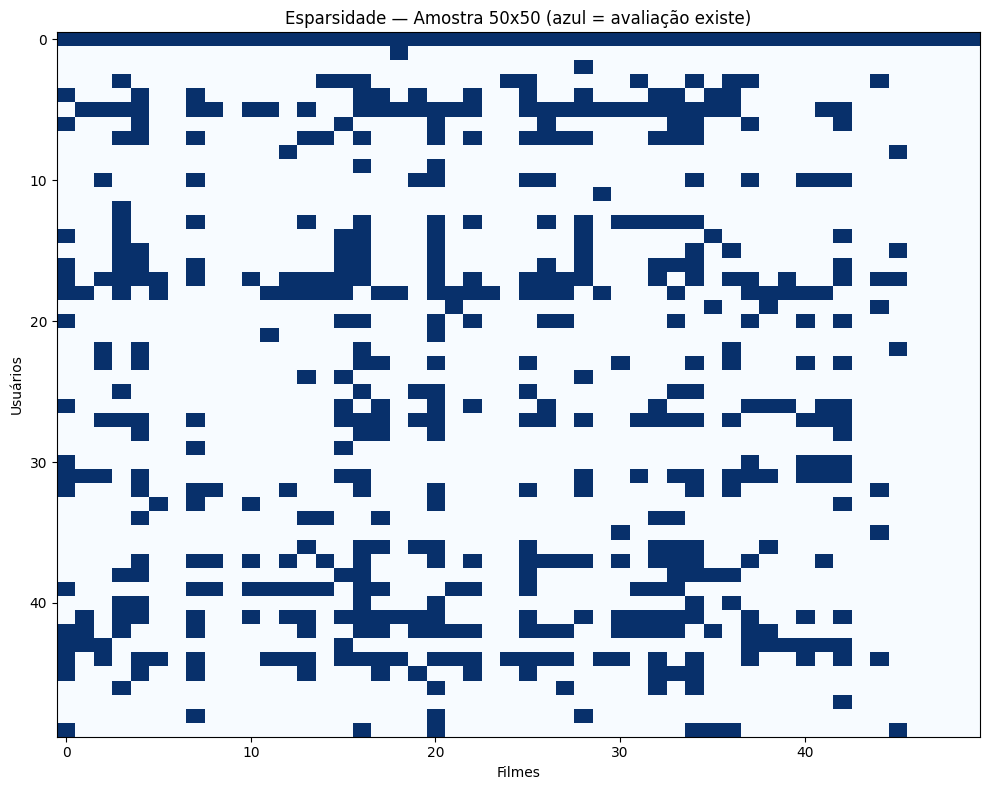

In [42]:
sample_users  = ratings['userId'].unique()[:50]
sample_movies = ratings['movieId'].unique()[:50]

sub = ratings[
    ratings['userId'].isin(sample_users) &
    ratings['movieId'].isin(sample_movies)
]

matrix = pd.crosstab(sub['userId'], sub['movieId'])
matrix = matrix.reindex(index=sample_users, columns=sample_movies, fill_value=0)

plt.figure(figsize=(10, 8))
plt.imshow(matrix > 0, cmap='Blues', aspect='auto')
plt.title('Esparsidade — Amostra 50x50 (azul = avaliação existe)')
plt.xlabel('Filmes')
plt.ylabel('Usuários')
plt.tight_layout()
plt.savefig('assets/esparsidade.png')
plt.show()

## 10. Conclusões



A análise dos dados mostrou que o conjunto apresenta **boa qualidade**, já que não foram identificados valores nulos nem duplicados.

As notas atribuídas pelos usuários se concentram principalmente entre **3.0 e 4.0**, o que indica uma tendência geral a avaliações positivas.

Tanto a distribuição de avaliações por usuário quanto por filme segue um padrão de **cauda longa** — poucos usuários e poucos filmes concentram a maior parte das interações, enquanto a maioria apresenta baixa atividade.

Um ponto relevante é que cerca de **25% dos filmes possuem apenas uma única avaliação**, o que pode representar um desafio para a construção de modelos de recomendação, especialmente em termos de generalização.

Em relação aos gêneros, categorias mais específicas como **Film-Noir** e **War** apresentam médias de avaliação mais altas, enquanto **Horror** tende a receber as piores avaliações.

Por fim, a matriz usuário-filme apresenta um alto nível de **esparsidade (98,30%)**, o que evidencia a necessidade do uso de técnicas apropriadas para lidar com dados esparsos e melhorar o desempenho do sistema de recomendação.